# Trabajo Práctico: Redes Neuronales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath(".."))
%load_ext autoreload
%autoreload 2

from src.MLP import MLP
from src.metrics import evaluate_model, plot_confusion_matrix

RANDOM_SEED = 1973

## 1. Análisis y Preprocesamiento de Datos


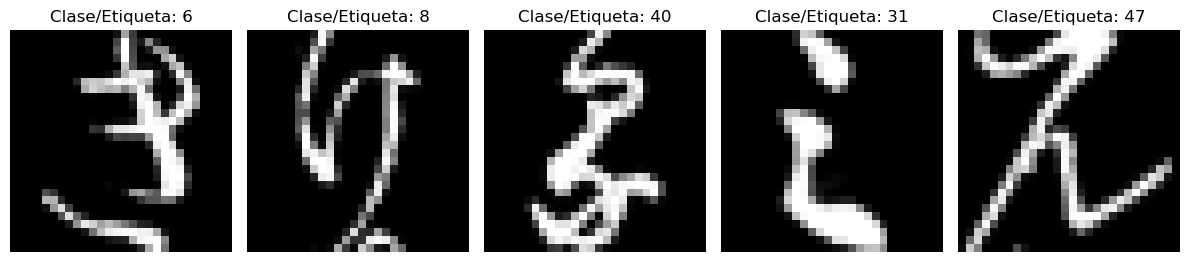

In [2]:
X_images = np . load ("../data/raw/X_images.npy")
y_images = np . load ("../data/raw/y_images.npy")
N = X_images.shape[0]

fig, axes = plt.subplots(1, 5, figsize=(12, 4))

np.random.seed(RANDOM_SEED)
for i in range(5):
    index = np.random.randint(0,N)
    img = X_images[index].reshape(28, 28)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Clase/Etiqueta: {y_images[index]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [3]:
np.random.seed(RANDOM_SEED)
num_samples = X_images.shape[0]

# arreglo con todos los índices mezclados aleatoriamente
indices = np.random.permutation(num_samples)

# separo en Dev (80%) y Test (20%)
dev_size = int(0.80 * num_samples)
dev_indices = indices[:dev_size]
test_indices = indices[dev_size:]
X_dev = X_images[dev_indices]
y_dev = y_images[dev_indices]
X_test = X_images[test_indices]
y_test = y_images[test_indices]


# separo Dev en train y validation
num_dev_samples = X_dev.shape[0]
train_size = int(0.80 * num_dev_samples)
X_train = X_dev[:train_size]
y_train = y_dev[:train_size]
X_val = X_dev[train_size:]
y_val = y_dev[train_size:]

print(f"Tamaño Total: {num_samples} imágenes\n")
print(f"Tamaño de Dev: {X_dev.shape[0]} imágenes")
print(f"Tamaño de Test: {X_test.shape[0]} imágenes\n")
print(f"  -> Tamaño de Train (dentro de Dev): {X_train.shape[0]} imágenes")
print(f"  -> Tamaño de Validation (dentro de Dev): {X_val.shape[0]} imágenes")


Tamaño Total: 5000 imágenes

Tamaño de Dev: 4000 imágenes
Tamaño de Test: 1000 imágenes

  -> Tamaño de Train (dentro de Dev): 3200 imágenes
  -> Tamaño de Validation (dentro de Dev): 800 imágenes


In [4]:
# Normalizar los datos dividiendo por 255
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# Verifico que el valor maximo ahora es 1
print(f"Valor máximo en Train antes de normalizar: {X_images.max()}")
print(f"Valor máximo en Train después de normalizar: {X_train.max()}")


Valor máximo en Train antes de normalizar: 255.0
Valor máximo en Train después de normalizar: 1.0


## 2. Implementación y Entrenamiento de una Red Neuronal Básica

#### Prueba de inicializacion de la red

In [5]:
n_layers = 2
# Lista con la cantidad de nodos por capa: [Entrada, Oculta 1, Salida]
nodes_per_layer = [784, 128, 49]
# Instanciamos la red neuronal
red_prueba = MLP(n_layers=n_layers, nodes_per_layer=nodes_per_layer, random_seed=42)
# Imprimimos la información para ver cómo quedó construida
red_prueba.print_info()

Numero de capas:  2
Numero de nodos por capa:  [784, 128, 49]
Capa  1 :  784 -> 128  con funcion de activacion  relu
Capa  2 :  128 -> 49  con funcion de activacion  softmax
Pesos de la capa 1:  [[ 0.02508785 -0.0069834   0.03271321 ... -0.06744508  0.01920289
   0.03083924]
 [ 0.02827369  0.05458767  0.04211943 ... -0.01420919  0.00338354
   0.02605887]
 [-0.07892048 -0.0267212   0.04011642 ... -0.01979963  0.05353487
   0.03116351]
 ...
 [-0.01520984 -0.02996139  0.07425277 ...  0.08622519 -0.0071112
   0.04780936]
 [ 0.04152834  0.03256375 -0.01150627 ... -0.08783793 -0.01636675
  -0.0307535 ]
 [ 0.08485768 -0.00966599 -0.03247982 ...  0.06209712  0.08136642
   0.07013439]]
Bias de la capa 1:  [[0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01

#### Prueba de entrenamiento mediante backpropagation y GD

Entrenando la red con 100 ejemplos durante 200 epochs...
Loss inicial: 3.9685
Loss final: 0.0647


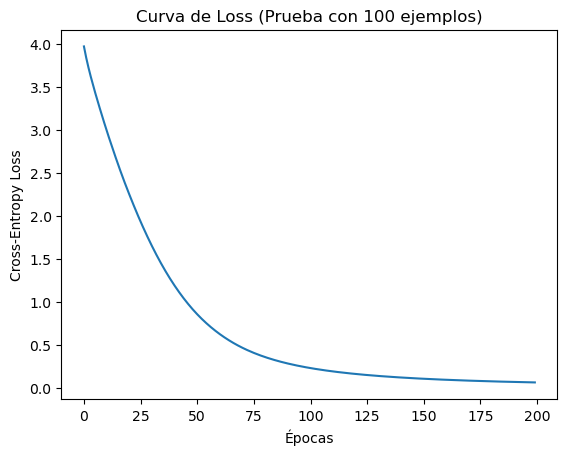

In [6]:
# Tomo una muestra chica
X_small = X_train[:100].T 
y_small_labels = y_train[:100]

# 2. Convierto y a One-Hot Encoding: shape (49 clases, 100 ejemplos)
y_small = np.zeros((49, 100))
for i in range(100):
    y_small[int(y_small_labels[i]), i] = 1

# Entreno la red de prueba anterior
print("Entrenando la red con 100 ejemplos durante 200 epochs...")
loss_history = red_prueba.fit(X_small, y_small, learning_rate=0.1, epochs=200)

print(f"Loss inicial: {loss_history[0]:.4f}")
print(f"Loss final: {loss_history[-1]:.4f}")

# Grafico la learning curve
plt.plot(loss_history)
plt.title("Curva de Loss (Prueba con 100 ejemplos)")
plt.xlabel("Épocas")
plt.ylabel("Cross-Entropy Loss")
plt.show()

A partir de los resultados obtenidos en esta prueba inicial, se verifica el correcto funcionamiento tanto de la arquitectura del MLP como de la implementación manual del algoritmo de backpropagation. La curva de aprendizaje exhibe una convergencia monótonamente decreciente, logrando reducir la función de costo (Cross-Entropy) desde un valor de 3.97 hasta un valor de 0.0647 en apenas 200 epochs. La capacidad del modelo para overfittear intencionalmente esta muestra reducida de 100 ejemplos demuestra de forma empírica que el cálculo analítico de los gradientes es matemáticamente preciso y que la actualización de los parámetros minimiza el error de manera efectiva.

#### Modelo M0

Entrenando M0 con Batch GD sobre todo el dataset...


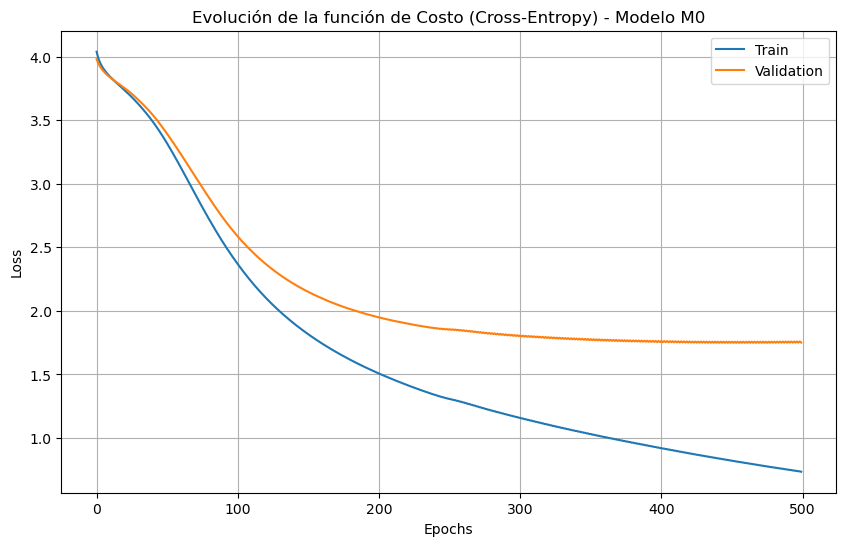

In [7]:
# M0: 2 capas ocultas (128 y 64 nodos). 
n_layers_M0 = 3
nodes_per_layer_M0 = [784, 128, 64, 49]

M0 = MLP(n_layers=n_layers_M0, nodes_per_layer=nodes_per_layer_M0, random_seed=RANDOM_SEED)

X_train_full = X_train.T  # Traspongo para que cada columna sea un dato
num_classes = 49
y_train_full = np.zeros((num_classes, len(y_train)))
for i in range(len(y_train)):
    y_train_full[int(y_train[i]), i] = 1

X_val_full = X_val.T      
y_val_full = np.zeros((num_classes, len(y_val)))
for i in range(len(y_val)):
    y_val_full[int(y_val[i]), i] = 1

print("Entrenando M0 con Batch GD sobre todo el dataset...")
# Le paso X_val e y_val para que vaya calculando el error de validation época a época
train_loss, val_loss = M0.fit(X_train_full, y_train_full, 
                              learning_rate=0.1, epochs=500, 
                              X_val=X_val_full, y_val=y_val_full)

# --- Gráfico de evolución de costo ---
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train')
plt.plot(val_loss, label='Validation')
plt.title('Evolución de la función de Costo (Cross-Entropy) - Modelo M0')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

--- Resultados para el Conjunto de Train ---
Cross-Entropy Loss : 0.7340
Accuracy           : 0.8272 (82.72%)
F1-Score (Macro)   : 0.8275

--- Resultados para el Conjunto de Validation ---
Cross-Entropy Loss : 1.7502
Accuracy           : 0.5763 (57.63%)
F1-Score (Macro)   : 0.5590



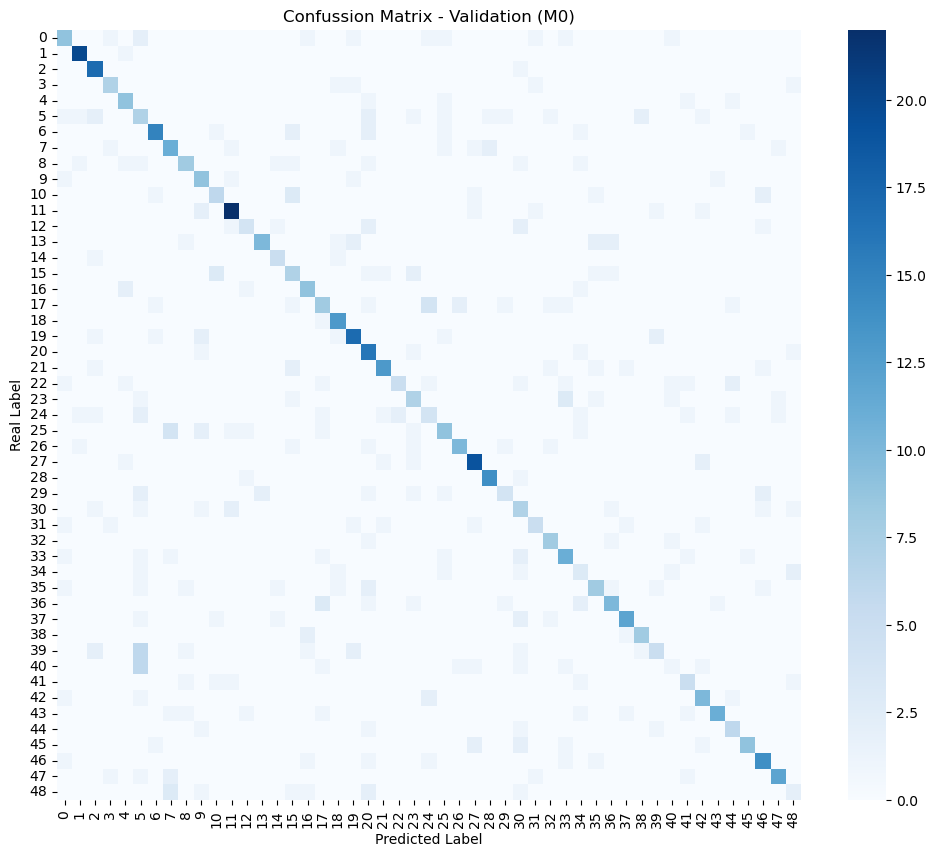

In [10]:
# Evaluar Entrenamiento
cm_train = evaluate_model(
    model=M0, 
    X=X_train_full, 
    y_one_hot=y_train_full, 
    y_labels=y_train, # Usamos el array original con las etiquetas crudas
    num_classes=num_classes, 
    name_set="Train"
)

# Evaluar Validación
cm_val = evaluate_model(
    model=M0, 
    X=X_val_full, 
    y_one_hot=y_val_full, 
    y_labels=y_val, 
    num_classes=num_classes, 
    name_set="Validation"
)

plot_confusion_matrix(cm_val, title="Confussion Matrix - Validation (M0)")

Al analizar las métricas obtenidas, identifico un claro escenario de overfitting. El modelo demuestra una excelente capacidad de aprendizaje sobre el conjunto de train, alcanzando un *accuracy* del **82.72%** y un *loss* de **0.73**, lo que confirma que el algoritmo de optimización está operando matemáticamente de forma correcta. No obstante, al evaluar sobre el conjunto de validation, se observa una marcada brecha de generalización: el *accuracy* desciende al **57.63%** y el costo se dispara a **1.75**, evidenciando que la red memorizó particularidades y ruido de la muestra de train en lugar de abstraer características generales. Para mitigar este efecto de memorización y lograr que el modelo generalice de forma más robusta sobre datos nuevos lo ideal seria implementar tecnicas de regularización.

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada
